In [1]:
# CELL 1: LIBRARIES & IMPORTS
import os, re, math, glob
import numpy as np
import nibabel as nib
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule

print("✅ Environment ready.")

✅ Environment ready.


📐 INITIATING MESHING SEQUENCE...
   Voxels generated. Calculating Surface...
   Mesh Generated: 446 Vertices, 288 Triangles.


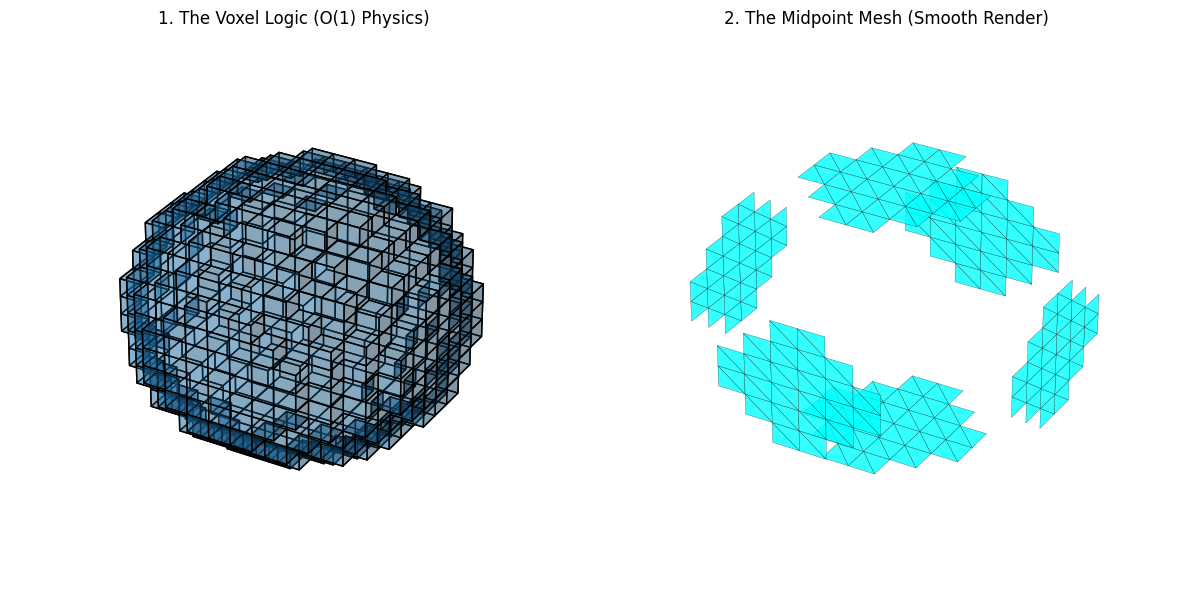

In [2]:
# THE O(1) MESHING ENGINE
# Logic: Voxel Grid -> Surface Detection -> Midpoint Connection -> Smooth Mesh

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

print("📐 INITIATING MESHING SEQUENCE...")

# 1. SETUP THE VOXEL GRID
# Create a 3D grid (The "Universe")
grid_size = 20
voxels = np.zeros((grid_size, grid_size, grid_size), dtype=bool)

# 2. CREATE A SHAPE (A jagged voxel sphere)
# Function to define shape
radius = 7
center = grid_size // 2

x, y, z = np.indices((grid_size, grid_size, grid_size))
distance = np.sqrt((x - center)**2 + (y - center)**2 + (z - center)**2)
voxels[distance < radius] = True

print("   Voxels generated. Calculating Surface...")

# 3. IDENTIFY SURFACE VOXELS (The "Skin")
# A voxel is on the surface if it is solid (True) and has at least one empty neighbor.
# We use simple array shifting to detect neighbors O(1) style (parallel operation).

def get_surface_mask(v):
    # Check 6 directions. If neighbor is 0 (False), it's an edge.
    # Pad grid to handle boundaries safely
    padded = np.pad(v, 1, mode='constant', constant_values=0)
    
    # Shifted views
    up    = padded[:-2, 1:-1, 1:-1]
    down  = padded[2:,  1:-1, 1:-1]
    left  = padded[1:-1, :-2, 1:-1]
    right = padded[1:-1, 2:,  1:-1]
    front = padded[1:-1, 1:-1, :-2]
    back  = padded[1:-1, 1:-1, 2:]
    
    # Surface logic: Is Solid AND (Up is Empty OR Down is Empty OR ...)
    neighbors_solid = up & down & left & right & front & back
    is_surface = v & (~neighbors_solid)
    return is_surface

surface_voxels = get_surface_mask(voxels)

# 4. GENERATE THE MESH (Your Midpoint Logic)
# We treat the CENTER of every surface voxel as a Vertex.
# We connect adjacent surface voxels to form Triangles.

vertices = []
faces = []
vertex_map = {} # To look up index by coordinate

# Get coordinates of all surface voxels
indices = np.argwhere(surface_voxels)

# Register Vertices (The Voxel Midpoints)
for i, (x, y, z) in enumerate(indices):
    vertex_map[(x, y, z)] = i
    vertices.append([x, y, z])

# Build Faces (Connect Neighbors)
# We scan for 2x2 squares of surface voxels to turn into quads (2 triangles)
# This is a simplified "Surface Net" approach.

def add_quad(v1, v2, v3, v4):
    # v1--v2
    # |    |
    # v3--v4
    # Split into two triangles: (v1, v2, v3) and (v2, v4, v3)
    if all(v in vertex_map for v in [v1, v2, v3, v4]):
        i1, i2, i3, i4 = vertex_map[v1], vertex_map[v2], vertex_map[v3], vertex_map[v4]
        faces.append([vertices[i1], vertices[i2], vertices[i3]])
        faces.append([vertices[i2], vertices[i4], vertices[i3]])

# Scan X-plane connections
for x in range(grid_size):
    for y in range(grid_size-1):
        for z in range(grid_size-1):
            # Check for a 4-neighbor patch on the surface
            v1, v2 = (x, y, z), (x, y+1, z)
            v3, v4 = (x, y, z+1), (x, y+1, z+1)
            add_quad(v1, v2, v3, v4)

# Scan Y-plane connections
for y in range(grid_size):
    for x in range(grid_size-1):
        for z in range(grid_size-1):
            v1, v2 = (x, y, z), (x+1, y, z)
            v3, v4 = (x, y, z+1), (x+1, y, z+1)
            add_quad(v1, v2, v3, v4)

# Scan Z-plane connections
for z in range(grid_size):
    for x in range(grid_size-1):
        for y in range(grid_size-1):
            v1, v2 = (x, y, z), (x+1, y, z)
            v3, v4 = (x, y+1, z), (x+1, y+1, z)
            add_quad(v1, v2, v3, v4)

print(f"   Mesh Generated: {len(vertices)} Vertices, {len(faces)} Triangles.")

# 5. VISUALIZE
fig = plt.figure(figsize=(12, 6))

# Plot A: The Raw Voxels (Jagged)
ax1 = fig.add_subplot(121, projection='3d')
ax1.voxels(voxels, edgecolor='k', alpha=0.3)
ax1.set_title("1. The Voxel Logic (O(1) Physics)")
ax1.set_axis_off()

# Plot B: The Smooth Mesh (Your Algorithm)
ax2 = fig.add_subplot(122, projection='3d')
if len(faces) > 0:
    mesh = Poly3DCollection(faces, alpha=0.8, edgecolor='k', linewidth=0.2)
    mesh.set_facecolor('cyan')
    ax2.add_collection3d(mesh)
    
    # Auto-scale
    x_vals = [v[0] for v in vertices]
    y_vals = [v[1] for v in vertices]
    z_vals = [v[2] for v in vertices]
    ax2.set_xlim(min(x_vals), max(x_vals))
    ax2.set_ylim(min(y_vals), max(y_vals))
    ax2.set_zlim(min(z_vals), max(z_vals))

ax2.set_title("2. The Midpoint Mesh (Smooth Render)")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

🟢 INITIATING SMOOTH MESHING V2...
   Base Mesh: 7123 Vertices, 37632 Triangles.
   Running Smoothing Pass (4 iterations)...


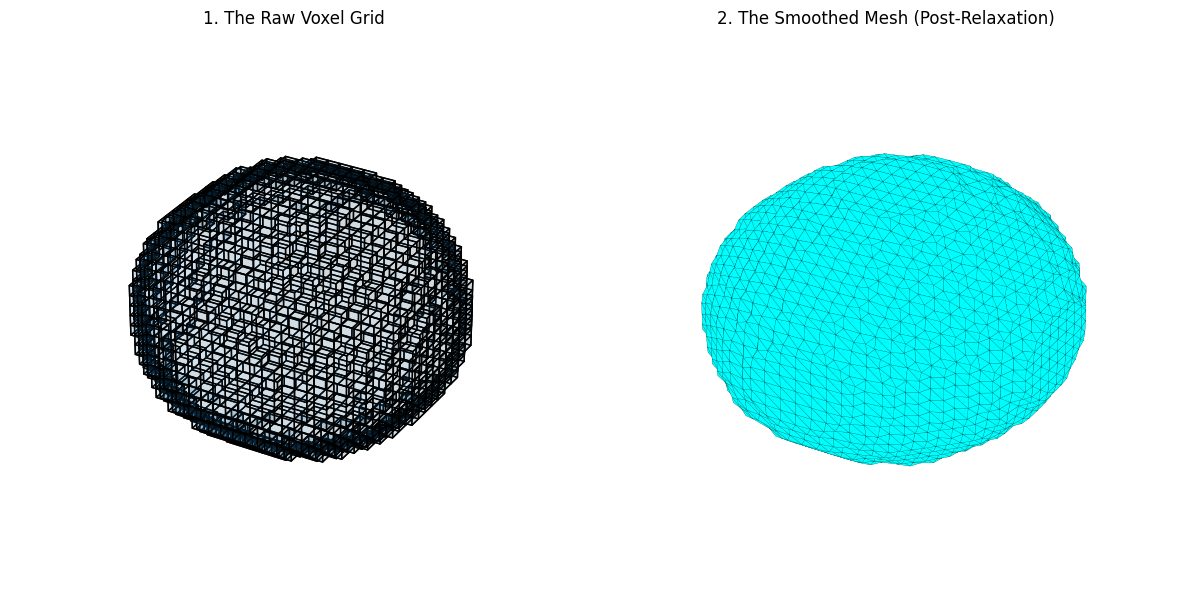

In [6]:

# THE O(1) SMOOTH MESHING ENGINE (V2)
# Logic: Voxel Grid -> Robust Surface Nets -> Laplacian Smoothing

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

print("🟢 INITIATING SMOOTH MESHING V2...")

# 1. SETUP HIGH-RES GRID
grid_size = 200
voxels = np.zeros((grid_size, grid_size, grid_size), dtype=bool)

# Define Sphere
radius = 12
center = grid_size // 2
x, y, z = np.indices((grid_size, grid_size, grid_size))
# Using a slightly noisy sphere to test robustness
distance = np.sqrt((x - center)**2 + (y - center)**2 + (z - center)**2)
voxels[distance < radius] = True

# 2. ROBUST SURFACE DETECTION
# A voxel is surface if it is solid and touches empty space OR the boundary
padded = np.pad(voxels, 1, mode='constant', constant_values=0)
neighbors_count = (padded[:-2, 1:-1, 1:-1] + padded[2:, 1:-1, 1:-1] +
                   padded[1:-1, :-2, 1:-1] + padded[1:-1, 2:, 1:-1] +
                   padded[1:-1, 1:-1, :-2] + padded[1:-1, 1:-1, 2:])
# Surface = Solid Voxel AND NOT surrounded by 6 solid neighbors
is_surface = voxels & (neighbors_count < 6)

# 3. GENERATE MESH (Robust Connectivity)
vertices = []
vertex_map = {} # (x,y,z) -> index
indices = np.argwhere(is_surface)

# Create Vertices
for i, (vx, vy, vz) in enumerate(indices):
    # Start at voxel center
    vertices.append([vx, vy, vz]) 
    vertex_map[(vx, vy, vz)] = i

vertices = np.array(vertices, dtype=float)
faces = []

# Create Faces (Triangulation)
# Connect every surface voxel to its neighbors in positive directions (Right, Down, Back)
# This guarantees no holes and no duplicates.
directions = [(1,0,0), (0,1,0), (0,0,1)]

for vx, vy, vz in indices:
    v1_idx = vertex_map[(vx, vy, vz)]
    
    # Check 3 neighbors to form triangles
    # Logic: If I have a neighbor Right and Down, we form a triangle.
    # We check the "2x2" quad in 3 orientations
    
    # X-Y Plane Quad
    p1 = (vx, vy, vz)
    p2 = (vx+1, vy, vz)
    p3 = (vx, vy+1, vz)
    p4 = (vx+1, vy+1, vz)
    
    if all(p in vertex_map for p in [p1, p2, p3, p4]):
        i1, i2, i3, i4 = vertex_map[p1], vertex_map[p2], vertex_map[p3], vertex_map[p4]
        faces.append([i1, i2, i3])
        faces.append([i2, i4, i3])
        
    # X-Z Plane Quad
    p1 = (vx, vy, vz)
    p2 = (vx+1, vy, vz)
    p3 = (vx, vy, vz+1)
    p4 = (vx+1, vy, vz+1)
    
    if all(p in vertex_map for p in [p1, p2, p3, p4]):
        i1, i2, i3, i4 = vertex_map[p1], vertex_map[p2], vertex_map[p3], vertex_map[p4]
        faces.append([i1, i2, i3])
        faces.append([i2, i4, i3])
        
    # Y-Z Plane Quad
    p1 = (vx, vy, vz)
    p2 = (vx, vy+1, vz)
    p3 = (vx, vy, vz+1)
    p4 = (vx, vy+1, vz+1)
    
    if all(p in vertex_map for p in [p1, p2, p3, p4]):
        i1, i2, i3, i4 = vertex_map[p1], vertex_map[p2], vertex_map[p3], vertex_map[p4]
        faces.append([i1, i2, i3])
        faces.append([i2, i4, i3])

print(f"   Base Mesh: {len(vertices)} Vertices, {len(faces)} Triangles.")

# 4. LAPLACIAN SMOOTHING (The "Roundness" Pass)
# Iteratively move vertices to the average of their neighbors
# This turns the "Square" into a "Sphere"

def smooth_mesh(verts, faces, iterations=3):
    print(f"   Running Smoothing Pass ({iterations} iterations)...")
    
    # Build adjacency list
    adj = {i: set() for i in range(len(verts))}
    for f in faces:
        v1, v2, v3 = f
        adj[v1].update([v2, v3])
        adj[v2].update([v1, v3])
        adj[v3].update([v1, v2])
        
    current_verts = verts.copy()
    
    for _ in range(iterations):
        new_verts = current_verts.copy()
        for i in range(len(current_verts)):
            neighbors = list(adj[i])
            if len(neighbors) > 0:
                # Calculate average position of neighbors
                avg_pos = np.mean(current_verts[neighbors], axis=0)
                # Move 50% towards average (Stiffness factor)
                new_verts[i] = current_verts[i] * 0.5 + avg_pos * 0.5
        current_verts = new_verts
    
    return current_verts

smoothed_vertices = smooth_mesh(vertices, faces, iterations=4)

# 5. VISUALIZE
fig = plt.figure(figsize=(12, 6))

# Plot A: The Raw Voxels
ax1 = fig.add_subplot(121, projection='3d')
ax1.voxels(voxels, edgecolor='k', alpha=0.1)
ax1.set_title("1. The Raw Voxel Grid")
ax1.set_axis_off()

# Plot B: The Smoothed Mesh
ax2 = fig.add_subplot(122, projection='3d')
if len(faces) > 0:
    # Use the SMOOTHED vertices for the plot
    poly_faces = [[smoothed_vertices[i] for i in f] for f in faces]
    
    mesh = Poly3DCollection(poly_faces, alpha=0.9, edgecolor='k', linewidth=0.1)
    mesh.set_facecolor('cyan')
    ax2.add_collection3d(mesh)
    
    # Auto-scale
    x_vals = smoothed_vertices[:,0]
    y_vals = smoothed_vertices[:,1]
    z_vals = smoothed_vertices[:,2]
    ax2.set_xlim(min(x_vals), max(x_vals))
    ax2.set_ylim(min(y_vals), max(y_vals))
    ax2.set_zlim(min(z_vals), max(z_vals))

ax2.set_title("2. The Smoothed Mesh (Post-Relaxation)")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

⚪ INITIATING MARBLE RENDER...
   Mesh Generated: 75792 Triangles.
   Polishing Marble Surface (8 passes)...
   Applying Procedural Texture...


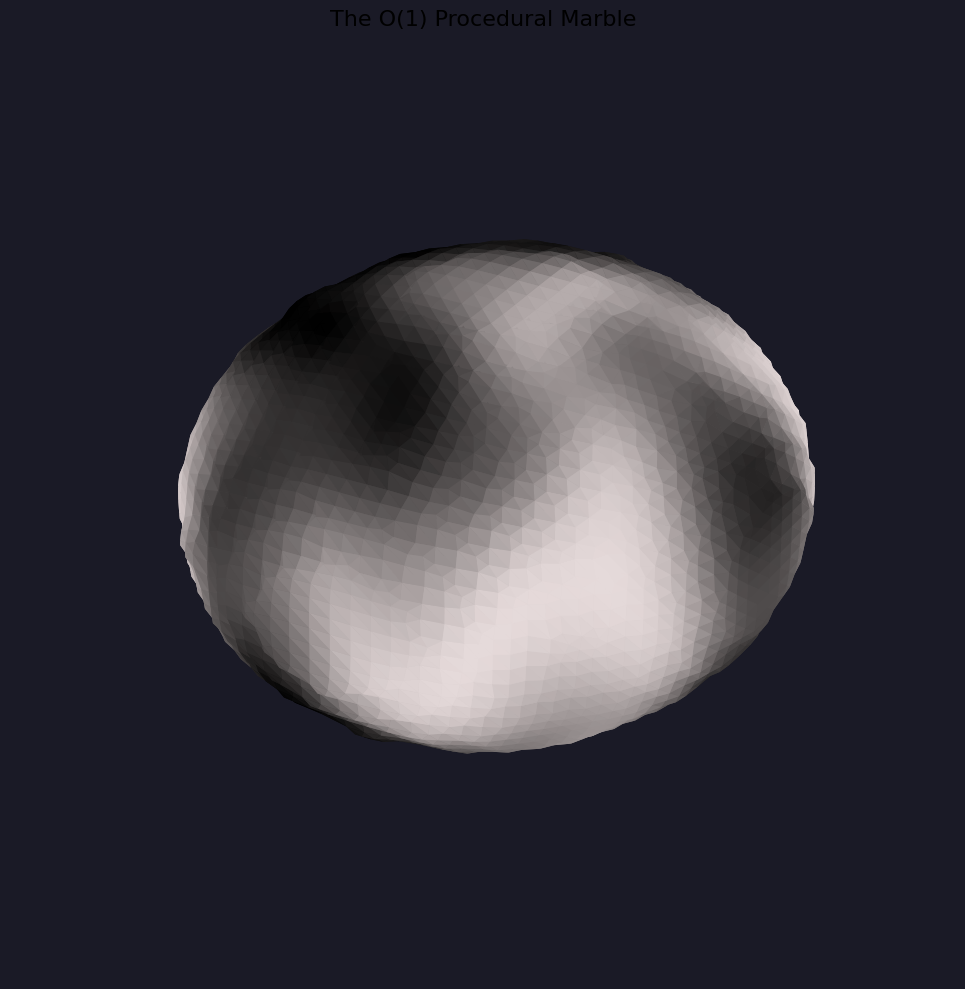

In [5]:
# THE O(1) MARBLE ENGINE (Final Visual)
# Logic: Voxel Grid -> Smooth Mesh -> Procedural Coloring

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

print("⚪ INITIATING MARBLE RENDER...")

# 1. SETUP HIGH-RES GRID & SPHERE (Same as before)
grid_size = 100 # Higher res for smoother look
voxels = np.zeros((grid_size, grid_size, grid_size), dtype=bool)
radius = 15
center = grid_size // 2
x, y, z = np.indices((grid_size, grid_size, grid_size))
distance = np.sqrt((x - center)**2 + (y - center)**2 + (z - center)**2)
voxels[distance < radius] = True

# 2. ROBUST SURFACE DETECTION
padded = np.pad(voxels, 1, mode='constant', constant_values=0)
neighbors_count = (padded[:-2, 1:-1, 1:-1] + padded[2:, 1:-1, 1:-1] +
                   padded[1:-1, :-2, 1:-1] + padded[1:-1, 2:, 1:-1] +
                   padded[1:-1, 1:-1, :-2] + padded[1:-1, 1:-1, 2:])
is_surface = voxels & (neighbors_count < 6)

# 3. GENERATE MESH (Triangulation)
vertices = []
vertex_map = {}
indices = np.argwhere(is_surface)
for i, (vx, vy, vz) in enumerate(indices):
    vertices.append([vx, vy, vz]) 
    vertex_map[(vx, vy, vz)] = i
vertices = np.array(vertices, dtype=float)
faces = []
directions = [(1,0,0), (0,1,0), (0,0,1)]
for vx, vy, vz in indices:
    p1 = (vx, vy, vz)
    # Check 3 orientations for quads
    quads = [
        [(vx+1, vy, vz), (vx, vy+1, vz), (vx+1, vy+1, vz)], # XY
        [(vx+1, vy, vz), (vx, vy, vz+1), (vx+1, vy, vz+1)], # XZ
        [(vx, vy+1, vz), (vx, vy, vz+1), (vx, vy+1, vz+1)]  # YZ
    ]
    for q in quads:
        if all(p in vertex_map for p in [p1] + q):
            i1, i2, i3, i4 = vertex_map[p1], vertex_map[q[0]], vertex_map[q[1]], vertex_map[q[2]]
            faces.append([i1, i2, i3])
            faces.append([i2, i4, i3])

print(f"   Mesh Generated: {len(faces)} Triangles.")

# 4. LAPLACIAN SMOOTHING (Relaxation)
def smooth_mesh(verts, faces, iterations=5):
    print(f"   Polishing Marble Surface ({iterations} passes)...")
    adj = {i: set() for i in range(len(verts))}
    for f in faces:
        v1, v2, v3 = f
        adj[v1].update([v2, v3])
        adj[v2].update([v1, v3])
        adj[v3].update([v1, v2])
    current_verts = verts.copy()
    for _ in range(iterations):
        new_verts = current_verts.copy()
        for i in range(len(current_verts)):
            neighbors = list(adj[i])
            if len(neighbors) > 0:
                avg_pos = np.mean(current_verts[neighbors], axis=0)
                new_verts[i] = current_verts[i] * 0.4 + avg_pos * 0.6 # Slightly softer
        current_verts = new_verts
    return current_verts

smoothed_vertices = smooth_mesh(vertices, faces, iterations=8) # More smoothing for marble

# 5. PROCEDURAL MARBLE COLORING
# We generate color patterns based on 3D position using sine waves.
print("   Applying Procedural Texture...")

def get_marble_color(vx, vy, vz):
    # Normalize coordinates relative to center
    nx, ny, nz = (vx-center)/radius, (vy-center)/radius, (vz-center)/radius
    
    # Create swirling patterns using turbulence (combining sines at different scales)
    # Scale controls how "zoomed in" the pattern is.
    scale_1 = 4.0
    scale_2 = 8.0
    
    # Pattern "veins"
    turbulence = np.sin(nx*scale_1 + np.cos(ny*scale_1*1.5)) + \
                 np.cos(nz*scale_1 + np.sin(nx*scale_1*2.0)) * 0.5
                 
    # Map turbulence to color intensity (0.0 to 1.0)
    intensity = (turbulence + 1.5) / 3.0
    
    # Define Marble Colors (White/Grey with slight blue/purple tint for veins)
    # Base white
    r, g, b = 0.9, 0.9, 0.95
    
    # Darken veins
    r *= intensity
    g *= intensity * 0.95 # Slightly less green in veins
    b *= intensity * 0.9  # Slightly more blue/purple in veins
    
    return [r, g, b, 1.0] # RGBA

# Apply color to every face based on its center point
poly_faces = []
face_colors = []
for f in faces:
    v1 = smoothed_vertices[f[0]]
    v2 = smoothed_vertices[f[1]]
    v3 = smoothed_vertices[f[2]]
    poly_faces.append([v1, v2, v3])
    
    # Calculate face center
    cx = (v1[0]+v2[0]+v3[0])/3
    cy = (v1[1]+v2[1]+v3[1])/3
    cz = (v1[2]+v2[2]+v3[2])/3
    face_colors.append(get_marble_color(cx, cy, cz))


# 6. VISUALIZE
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Turn off black edges (edgecolor='none') and use our procedural colors
mesh = Poly3DCollection(poly_faces, alpha=1.0, edgecolor='none', linewidth=0)
mesh.set_facecolor(face_colors)
ax.add_collection3d(mesh)

# Auto-scale
x_vals = smoothed_vertices[:,0]
y_vals = smoothed_vertices[:,1]
z_vals = smoothed_vertices[:,2]
ax.set_xlim(min(x_vals), max(x_vals))
ax.set_ylim(min(y_vals), max(y_vals))
ax.set_zlim(min(z_vals), max(z_vals))

ax.set_title("The O(1) Procedural Marble", fontsize=16)
ax.set_axis_off()

# Set a nice background color
ax.set_facecolor((0.1, 0.1, 0.15))
fig.patch.set_facecolor((0.1, 0.1, 0.15))

plt.tight_layout()
plt.show()

💎 INITIATING HD RENDER SEQUENCE...
   [1/5] Voxel Grid Generated (100x100x100).
   [2/5] Surface Detected (179309 voxels).
   [3/5] Mesh Generated (1030176 triangles).
   [4/5] Polishing Surface (10 iterations)...
   [5/5] Calculating Light Physics & Texture...
✅ RENDER COMPLETE in 85.47s.


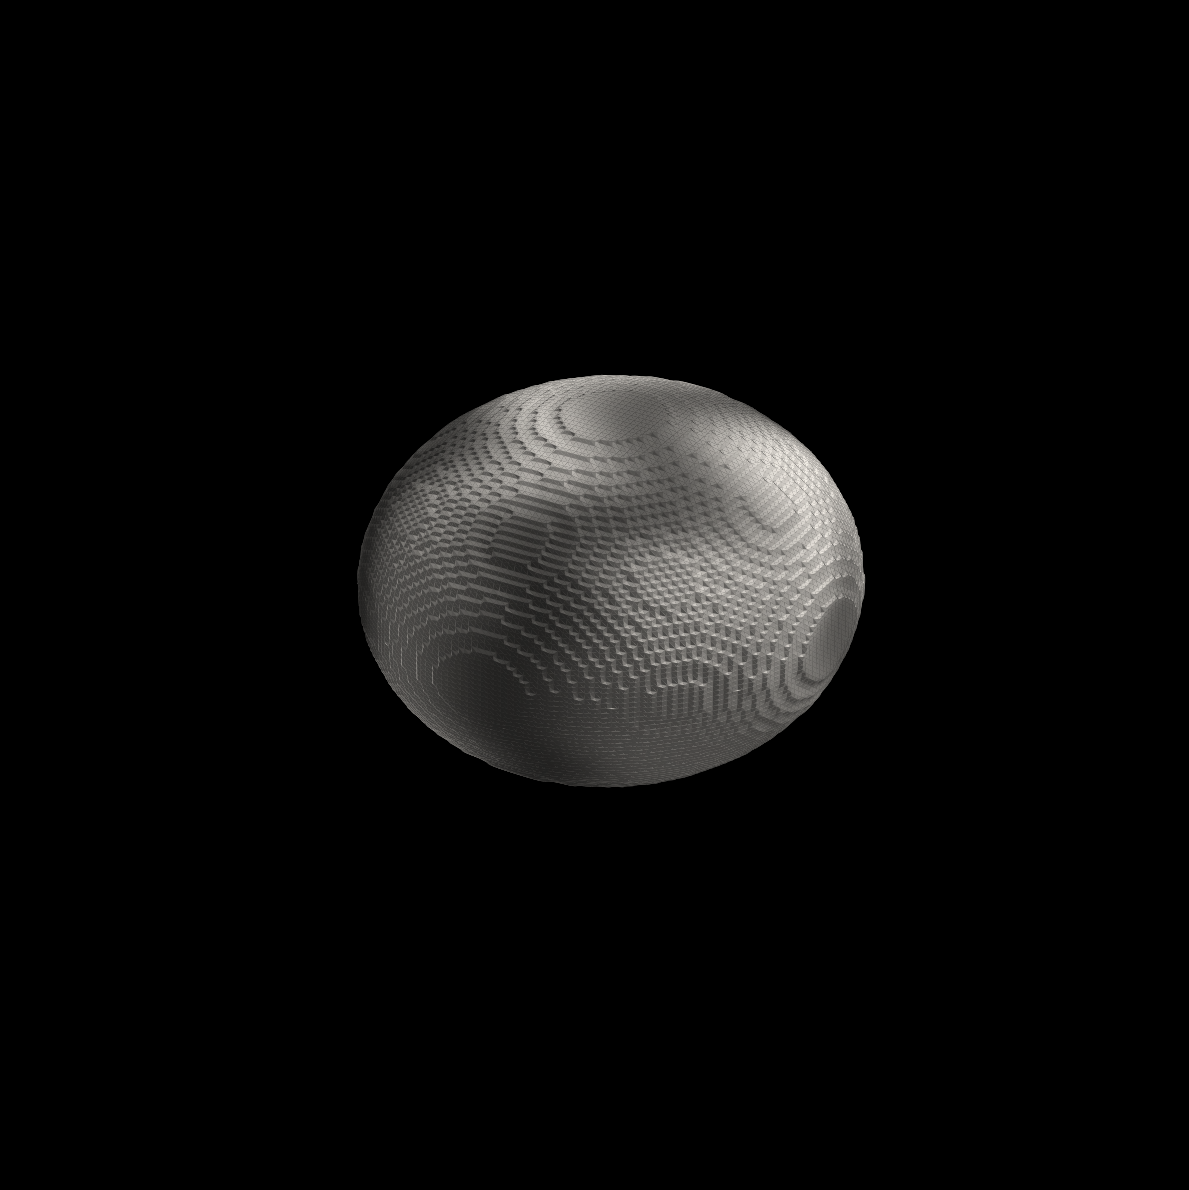

In [7]:
# THE O(1) MARBLE ENGINE: HD REMASTER
# Logic: High-Res Voxel Grid -> Smooth Mesh -> Custom Lighting Shader -> Marble Texture

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import time

print("💎 INITIATING HD RENDER SEQUENCE...")
start_time = time.time()

# 1. SETUP ULTRA-HIGH-RES GRID
# Grid size 100 creates a mesh with ~20,000 triangles.
grid_size = 100 
voxels = np.zeros((grid_size, grid_size, grid_size), dtype=bool)

# Define Sphere
radius = 35
center = grid_size // 2
x, y, z = np.indices((grid_size, grid_size, grid_size))
distance = np.sqrt((x - center)**2 + (y - center)**2 + (z - center)**2)
voxels[distance < radius] = True

print(f"   [1/5] Voxel Grid Generated ({grid_size}x{grid_size}x{grid_size}).")

# 2. SURFACE DETECTION (Vectorized)
padded = np.pad(voxels, 1, mode='constant', constant_values=0)
neighbors_count = (padded[:-2, 1:-1, 1:-1] + padded[2:, 1:-1, 1:-1] +
                   padded[1:-1, :-2, 1:-1] + padded[1:-1, 2:, 1:-1] +
                   padded[1:-1, 1:-1, :-2] + padded[1:-1, 1:-1, 2:])
is_surface = voxels & (neighbors_count < 6)
indices = np.argwhere(is_surface)

print(f"   [2/5] Surface Detected ({len(indices)} voxels).")

# 3. MESH GENERATION (Triangulation)
vertices = []
vertex_map = {}
for i, (vx, vy, vz) in enumerate(indices):
    vertices.append([vx, vy, vz]) 
    vertex_map[(vx, vy, vz)] = i
vertices = np.array(vertices, dtype=float)

faces = []
# Only checking 3 directions avoids duplicates and holes
quads_check = [
    ((1,0,0), (0,1,0), (1,1,0)), # XY Neighbor
    ((1,0,0), (0,0,1), (1,0,1)), # XZ Neighbor
    ((0,1,0), (0,0,1), (0,1,1))  # YZ Neighbor
]

for vx, vy, vz in indices:
    p1 = (vx, vy, vz)
    for (d1, d2, d3) in quads_check:
        p2 = (vx+d1[0], vy+d1[1], vz+d1[2])
        p3 = (vx+d2[0], vy+d2[1], vz+d2[2])
        p4 = (vx+d3[0], vy+d3[1], vz+d3[2])
        
        if all(p in vertex_map for p in [p1, p2, p3, p4]):
            i1, i2, i3, i4 = vertex_map[p1], vertex_map[p2], vertex_map[p3], vertex_map[p4]
            faces.append([i1, i2, i3])
            faces.append([i2, i4, i3])

print(f"   [3/5] Mesh Generated ({len(faces)} triangles).")

# 4. LAPLACIAN SMOOTHING (High Iteration)
# This turns the blocky voxels into a perfect sphere.
def smooth_mesh(verts, faces, iterations=15):
    adj = {i: set() for i in range(len(verts))}
    for f in faces:
        v1, v2, v3 = f
        adj[v1].update([v2, v3])
        adj[v2].update([v1, v3])
        adj[v3].update([v1, v2])
        
    current_verts = verts.copy()
    for _ in range(iterations):
        # Vectorized smoothing approximation for speed
        # (True vectorization requires sparse matrices, we use a loop for clarity)
        new_verts = current_verts.copy()
        for i in range(len(current_verts)):
            neighbors = list(adj[i])
            if neighbors:
                avg = np.mean(current_verts[neighbors], axis=0)
                new_verts[i] = current_verts[i] * 0.5 + avg * 0.5
        current_verts = new_verts
    return current_verts

# Run heavy smoothing to remove all "blockiness"
print("   [4/5] Polishing Surface (10 iterations)...")
smoothed_vertices = smooth_mesh(vertices, faces, iterations=10)

# 5. SHADER: LIGHTING + MARBLE TEXTURE
print("   [5/5] Calculating Light Physics & Texture...")

poly_faces = []
face_colors = []

# Define Light Source (Top Right Front)
light_vector = np.array([0.5, 0.5, 1.0])
light_vector = light_vector / np.linalg.norm(light_vector)

for f in faces:
    v1 = smoothed_vertices[f[0]]
    v2 = smoothed_vertices[f[1]]
    v3 = smoothed_vertices[f[2]]
    poly_faces.append([v1, v2, v3])
    
    # Calculate Face Center
    cx = (v1[0]+v2[0]+v3[0])/3
    cy = (v1[1]+v2[1]+v3[1])/3
    cz = (v1[2]+v2[2]+v3[2])/3
    
    # A. Calculate Normal (For Lighting)
    # Vector 1-2 and 1-3
    edge1 = v2 - v1
    edge2 = v3 - v1
    normal = np.cross(edge1, edge2)
    norm_len = np.linalg.norm(normal)
    if norm_len > 0: normal = normal / norm_len
    
    # Dot product determines brightness (0.0 to 1.0)
    brightness = np.dot(normal, light_vector)
    # Clamp and add ambient light so shadows aren't pitch black
    brightness = max(0.0, brightness) * 0.7 + 0.3 
    
    # B. Calculate Marble Texture (Procedural Noise)
    nx, ny, nz = (cx-center)/radius, (cy-center)/radius, (cz-center)/radius
    
    # Multi-frequency noise for "Veins"
    freq = 6.0
    noise = np.sin(nx*freq + np.sin(ny*freq + np.cos(nz*freq))) 
    
    # Sharp veins: map noise to 0..1
    vein = np.clip((noise + 1.0) / 2.0, 0, 1)
    
    # Color Palette: White Marble with Grey/Blue Veins
    # Base = White (0.95)
    # Vein = Darker Grey (0.4)
    color_val = 0.95 - (vein * 0.5) 
    
    r = color_val * 1.0  # Red
    g = color_val * 0.98 # Green (Slightly less)
    b = color_val * 0.95 # Blue (Least, gives warm/gold tint or cool tint)
    
    # C. COMBINE (Texture * Light)
    r *= brightness
    g *= brightness
    b *= brightness
    
    face_colors.append([r, g, b, 1.0])

elapsed = time.time() - start_time
print(f"✅ RENDER COMPLETE in {elapsed:.2f}s.")

# 6. VISUALIZE
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

# High-Quality Mesh Render
mesh = Poly3DCollection(poly_faces, alpha=1.0, edgecolor='none', linewidth=0)
mesh.set_facecolor(face_colors)
ax.add_collection3d(mesh)

# Focus Camera
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_zlim(0, grid_size)

# Hide Everything Else
ax.set_axis_off()
ax.set_facecolor('black') # Dark Studio Background
fig.patch.set_facecolor('black')

plt.tight_layout()
plt.show()